In [1]:
import time

import pandas as pd

from sklearn.datasets import fetch_openml

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report
)

In [2]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data / 255.0
y = mnist.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [4]:
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

In [5]:
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [0.001, 0.01, "scale"],
    "kernel": ["rbf"]
}

In [6]:
grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [7]:
start = time.time()

grid_search.fit(
    X_train_small,
    y_train_small
)

end = time.time()

print("Training Time:", end-start)

Training Time: 78.47317004203796


In [8]:
print(grid_search.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [9]:
print(grid_search.best_score_)

0.958


In [10]:
best_model = grid_search.best_estimator_

In [11]:
y_pred = best_model.predict(X_test)

print("Accuracy")

print(accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy
0.9572857142857143
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1381
           1       0.97      0.99      0.98      1575
           2       0.95      0.95      0.95      1398
           3       0.95      0.94      0.95      1428
           4       0.96      0.95      0.95      1365
           5       0.96      0.95      0.95      1263
           6       0.96      0.98      0.97      1375
           7       0.96      0.96      0.96      1459
           8       0.96      0.93      0.95      1365
           9       0.94      0.93      0.94      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



In [12]:
results = pd.DataFrame(grid_search.cv_results_)

results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_gamma,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,22.370286,0.412969,3.145578,0.279361,0.1,0.001,rbf,"{'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}",0.724,0.702,0.736,0.704,0.738,0.7208,0.015315,9
1,13.417417,1.759545,2.142823,0.207276,0.1,0.01,rbf,"{'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}",0.897,0.893,0.904,0.898,0.911,0.9006,0.006280,7
2,16.896728,0.421869,2.280485,0.095000,0.1,scale,rbf,"{'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}",0.902,0.903,0.908,0.907,0.915,0.9070,0.004604,6
3,11.926786,0.608613,2.144487,0.267636,1.0,0.001,rbf,"{'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}",0.900,0.895,0.893,0.896,0.902,0.8972,0.003311,8
4,7.337364,0.217696,1.536905,0.080094,1.0,0.01,rbf,"{'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}",0.946,0.938,0.942,0.950,0.946,0.9444,0.004079,4


In [13]:
results.to_csv(
    "../data/grid_search_results.csv",
    index=False
)

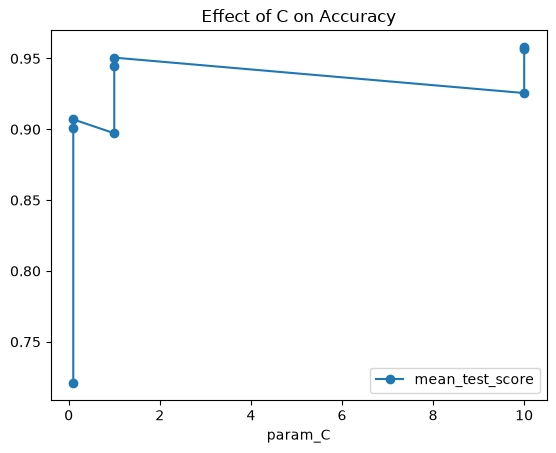

In [14]:
import matplotlib.pyplot as plt

results.plot(
    x="param_C",
    y="mean_test_score",
    marker="o"
)

plt.title("Effect of C on Accuracy")

plt.show()